# Single-band Photometry and 7DT-FINALCAT Master Catalog

This notebook is the complete Notebook 2 pipeline. It constructs or loads the
single-band catalogs, matches the 20 7DT bands, adds valid-footprint FINALCAT
sources as a final pseudo-band, writes the union master catalog, and produces
the compact diagnostics required to validate the matching result.


## 1. Setup


In [1]:
from pathlib import Path
import subprocess
import warnings

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord, search_around_sky
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.table import MaskedColumn, Table
from astropy.visualization import ImageNormalize, ZScaleInterval
from astropy.units import UnitsWarning
from astropy.wcs import FITSFixedWarning, WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from matplotlib.patches import Circle
from scipy.spatial import cKDTree
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UnitsWarning)
warnings.filterwarnings("ignore", category=FITSFixedWarning)


def project_root():
    cwd = Path.cwd().resolve()
    return cwd.parent if cwd.name == "Notebooks" else cwd


PROJECT_ROOT = project_root()
COSMOS = 1
DATA_ROOT = PROJECT_ROOT / "COSMOS_data"
BANDS_7DT = [f"m{i}" for i in range(400, 900, 25)]
MASK_PATH = DATA_ROOT / f"COSMOS{COSMOS}/COSMOS{COSMOS}_validmask.fits"
FINALCAT_PATH = DATA_ROOT / "COSMOS_finalcat.fits"
SINGLE_DIR = PROJECT_ROOT / f"output/COSMOS{COSMOS}/singlebandphot"
MATCH_DIR = SINGLE_DIR / "matching"
MATCH_FIG_DIR = MATCH_DIR / "figures"


def get_image_path(cosmos, band, weight=False):
    image_dir = DATA_ROOT / f"COSMOS{cosmos}"
    suffix = "weight.fits" if weight else "com.fits"
    paths = list(image_dir.glob(f"*{band}*.{suffix}"))
    if len(paths) != 1:
        raise FileNotFoundError(
            f"Expected one COSMOS{cosmos} {band} {suffix} image, found {len(paths)}"
        )
    return paths[0]


def get_catalog_path(cosmos, band):
    return SINGLE_DIR / f"cat_cosmos{cosmos}_{band}.fits"


valid_mask = fits.getdata(MASK_PATH).astype(bool)
available_band = []
image_paths = {}
weight_paths = {}
zero_points = {}

for band in BANDS_7DT:
    try:
        image_path = get_image_path(COSMOS, band)
        weight_path = get_image_path(COSMOS, band, weight=True)
    except FileNotFoundError as exc:
        print(exc)
        continue
    available_band.append(band)
    image_paths[band] = image_path
    weight_paths[band] = weight_path
    zero_points[band] = float(fits.getheader(image_path)["ZP_3"])

if not available_band:
    raise RuntimeError("No 7DT bands are available")

first_band = available_band[0]
reference_data = fits.getdata(image_paths[first_band])
wcs = WCS(fits.getheader(image_paths[first_band]))
PIXEL_SCALE = (proj_plane_pixel_scales(wcs)[0] * u.deg).to(u.arcsec)
APER_3ARCSEC_PIXEL = (3 * u.arcsec / PIXEL_SCALE).value
DETECTION_THRESHOLD = 3
DETECTION_MINIMUM_AREA = 3
THREAD_COUNT = 1


def positions_in_valid_mask(x, y, origin=1):
    """Return membership in the NumPy valid mask for pixel coordinates."""
    x0 = np.asarray(x, dtype=float) - float(origin)
    y0 = np.asarray(y, dtype=float) - float(origin)
    finite = np.isfinite(x0) & np.isfinite(y0)
    ix = np.zeros(len(x0), dtype=int)
    iy = np.zeros(len(y0), dtype=int)
    ix[finite] = np.rint(x0[finite]).astype(int)
    iy[finite] = np.rint(y0[finite]).astype(int)
    inside = (
        finite
        & (ix >= 0)
        & (ix < valid_mask.shape[1])
        & (iy >= 0)
        & (iy < valid_mask.shape[0])
    )
    selected = np.zeros(len(x0), dtype=bool)
    selected[inside] = valid_mask[iy[inside], ix[inside]]
    return selected


def select_singleband_sources(cat):
    finite = (
        np.isfinite(np.asarray(cat["pixel_centroid_x"], dtype=float))
        & np.isfinite(np.asarray(cat["pixel_centroid_y"], dtype=float))
        & np.isfinite(np.asarray(cat["aper3_mag"], dtype=float))
        & np.isfinite(np.asarray(cat["flux_radius"], dtype=float))
    )
    selected = (
        finite
        & (np.asarray(cat["aper3_flags"]) == 0)
        & (np.asarray(cat["flux_radius"], dtype=float) > 0)
        & (np.asarray(cat["aper3_mag"], dtype=float) > 5)
    )
    selected &= positions_in_valid_mask(
        cat["pixel_centroid_x"], cat["pixel_centroid_y"], origin=1
    )
    return cat[selected]


print(f"Project root: {PROJECT_ROOT}")
print(f"Available bands: {len(available_band)}")
print(f"Pixel scale: {PIXEL_SCALE.value:.4f} arcsec/pixel")


Project root: /Users/mac_seo/Research_local/7DTonCOSMOS
Available bands: 20
Pixel scale: 0.5050 arcsec/pixel


### 1.1 Run control


In [2]:
OVERWRITE_PHOTOMETRY = False
OVERWRITE_MATCHING = False
FINALCAT_MATCH_RADIUS_ARCSEC = 0.7
FINALCAT_RADIUS_GRID_ARCSEC = (0.5, 0.7, 1.0)
RANDOM_SHIFTS_ARCSEC = (
    (10.0, 0.0), (-10.0, 0.0), (0.0, 10.0), (0.0, -10.0),
    (20.0, 0.0), (-20.0, 0.0), (0.0, 20.0), (0.0, -20.0),
)

print(f"OVERWRITE_PHOTOMETRY={OVERWRITE_PHOTOMETRY}")
print(f"OVERWRITE_MATCHING={OVERWRITE_MATCHING}")
print(f"FINALCAT_MATCH_RADIUS_ARCSEC={FINALCAT_MATCH_RADIUS_ARCSEC}")


OVERWRITE_PHOTOMETRY=False
OVERWRITE_MATCHING=False
FINALCAT_MATCH_RADIUS_ARCSEC=0.7


## 2. Single-band Photometry


In [3]:
bands_to_run = (
    list(available_band)
    if OVERWRITE_PHOTOMETRY
    else [band for band in available_band if not get_catalog_path(COSMOS, band).exists()]
)

if not bands_to_run:
    print("All single-band catalogs exist; skipping SourceXtractor++.")

for band in tqdm(bands_to_run):
    image_path = image_paths[band]
    weight_path = weight_paths[band]
    catalog_path = get_catalog_path(COSMOS, band)
    pyconfig_path = PROJECT_ROOT / f"seppconfig/singlephot_cosmos{COSMOS}_{band}.py"
    config_path = PROJECT_ROOT / f"seppconfig/singlephot_cosmos{COSMOS}_{band}.config"
    pyconfig_path.parent.mkdir(parents=True, exist_ok=True)
    catalog_path.parent.mkdir(parents=True, exist_ok=True)

    pyconfig_code = f"""
from sourcextractor.config import *

image_group = load_fits_image({str(image_path)!r})
meas_group = MeasurementGroup(image_group)
aper = []
for img in meas_group:
    aper.extend(add_aperture_photometry(img, {float(APER_3ARCSEC_PIXEL)!r}))
add_output_column("aper3", aper)
"""

    config_code = f"""
detection-image={image_path}
detection-threshold={DETECTION_THRESHOLD}
detection-minimum-area={DETECTION_MINIMUM_AREA}
magnitude-zero-point={zero_points[band]}
python-config-file={pyconfig_path}
output-properties=SourceIDs,PixelCentroid,WorldCentroid,AperturePhotometry,SNRRatio,ShapeParameters,FluxRadius
output-catalog-filename={catalog_path}
segmentation-use-filtering=false
thread-count={THREAD_COUNT}
"""
    pyconfig_path.write_text(pyconfig_code)
    config_path.write_text(config_code)
    subprocess.run(["sourcextractor++", "--config-file", str(config_path)], check=True)

print("Single-band photometry products are ready.")


All single-band catalogs exist; skipping SourceXtractor++.


0it [00:00, ?it/s]

Single-band photometry products are ready.


### 2.1 Common source selection

The same filtered catalogs are used by the diagnostic plots, uncertainty
measurement, and cross-band matcher.


In [4]:
catalogs = {}
matching_catalogs = {}

for band in available_band:
    cat = Table.read(get_catalog_path(COSMOS, band))
    catalogs[band] = cat
    matching_catalogs[band] = select_singleband_sources(cat)
    print(f"{band}: {len(matching_catalogs[band])}/{len(cat)} selected")


m400: 1823/8109 selected
m425: 3492/16002 selected
m450: 2468/43854 selected
m475: 4174/32923 selected
m500: 4003/8158 selected
m525: 5335/22293 selected
m550: 2936/15201 selected
m575: 6013/43877 selected
m600: 3144/13405 selected
m625: 5182/25124 selected
m650: 2887/6733 selected
m675: 6226/22981 selected
m700: 3703/19306 selected
m725: 4825/27380 selected
m750: 3872/16406 selected
m775: 4166/30469 selected
m800: 5172/28244 selected
m825: 3822/121449 selected
m850: 3020/31718 selected
m875: 2619/36936 selected


### 2.2 Per-band Positional Scale


In [5]:
r50_statistics = {}
band_fwhm = {}
band_snrratio_min = {}
band_sigma = {}
band_sigma_arcsec = {}
band_matching_count = {}
band_rows = []
pixel_scale_value = float(PIXEL_SCALE.value)

for band in available_band:
    cat = matching_catalogs[band]
    radius = np.asarray(cat["flux_radius"], dtype=float)
    r50_mean, r50_med, r50_std = sigma_clipped_stats(radius)
    snr = np.asarray(cat["snrratio"], dtype=float)
    valid_snr = snr[np.isfinite(snr) & (snr > 0)]
    if not np.isfinite(r50_med) or r50_med <= 0 or not len(valid_snr):
        raise ValueError(f"Cannot define positional scale for {band}")
    fwhm_pix = 2.0 * float(r50_med)
    min_snr = float(valid_snr.min())
    sigma_pix = fwhm_pix / (2.355 * min_snr)
    r50_statistics[band] = (float(r50_mean), float(r50_med), float(r50_std))
    band_fwhm[band] = fwhm_pix
    band_snrratio_min[band] = min_snr
    band_sigma[band] = sigma_pix
    band_sigma_arcsec[band] = sigma_pix * pixel_scale_value
    band_matching_count[band] = len(cat)
    band_rows.append({
        "band": band,
        "n_matching": len(cat),
        "r50_med": float(r50_med),
        "fwhm_pix": fwhm_pix,
        "min_snrratio": min_snr,
        "sigma_pix": sigma_pix,
        "sigma_arcsec": sigma_pix * pixel_scale_value,
    })

band_uncertainty = Table(rows=band_rows)
MATCH_DIR.mkdir(parents=True, exist_ok=True)
band_uncertainty.write(MATCH_DIR / "band_uncertainty.fits", overwrite=True)
band_uncertainty.pprint(max_width=-1)


band n_matching      r50_med            fwhm_pix         min_snrratio         sigma_pix          sigma_arcsec   
---- ---------- ------------------ ------------------ ------------------ ------------------- -------------------
m400       1823  2.585671067237854  5.171342134475708  5.080752849578857  0.4321995303733587 0.21826076283858067
m425       3492  2.874722480773926  5.749444961547852   5.20346212387085  0.4691833715465925 0.23693760263106672
m450       2468  2.827381134033203  5.654762268066406  5.207528114318848  0.4610964904837374 0.23285372769432425
m475       4174 2.9796385765075684  5.959277153015137 5.1719865798950195  0.4892662775024473   0.247079470138775
m500       4003 2.4346041679382324  4.869208335876465  5.137638092041016  0.4024425916862922 0.20323350880160973
m525       5335 2.7083563804626465  5.416712760925293 5.1740803718566895 0.44454089983851097 0.22449315441848358
m550       2936 3.0634803771972656  6.126960754394531  5.222823143005371  0.4981370760149298 0.2

### 2.3 Matching-input Summary

This is the only retained single-band figure. It summarizes the source counts
and positional-scale inputs used by the matcher without producing one figure
per band.


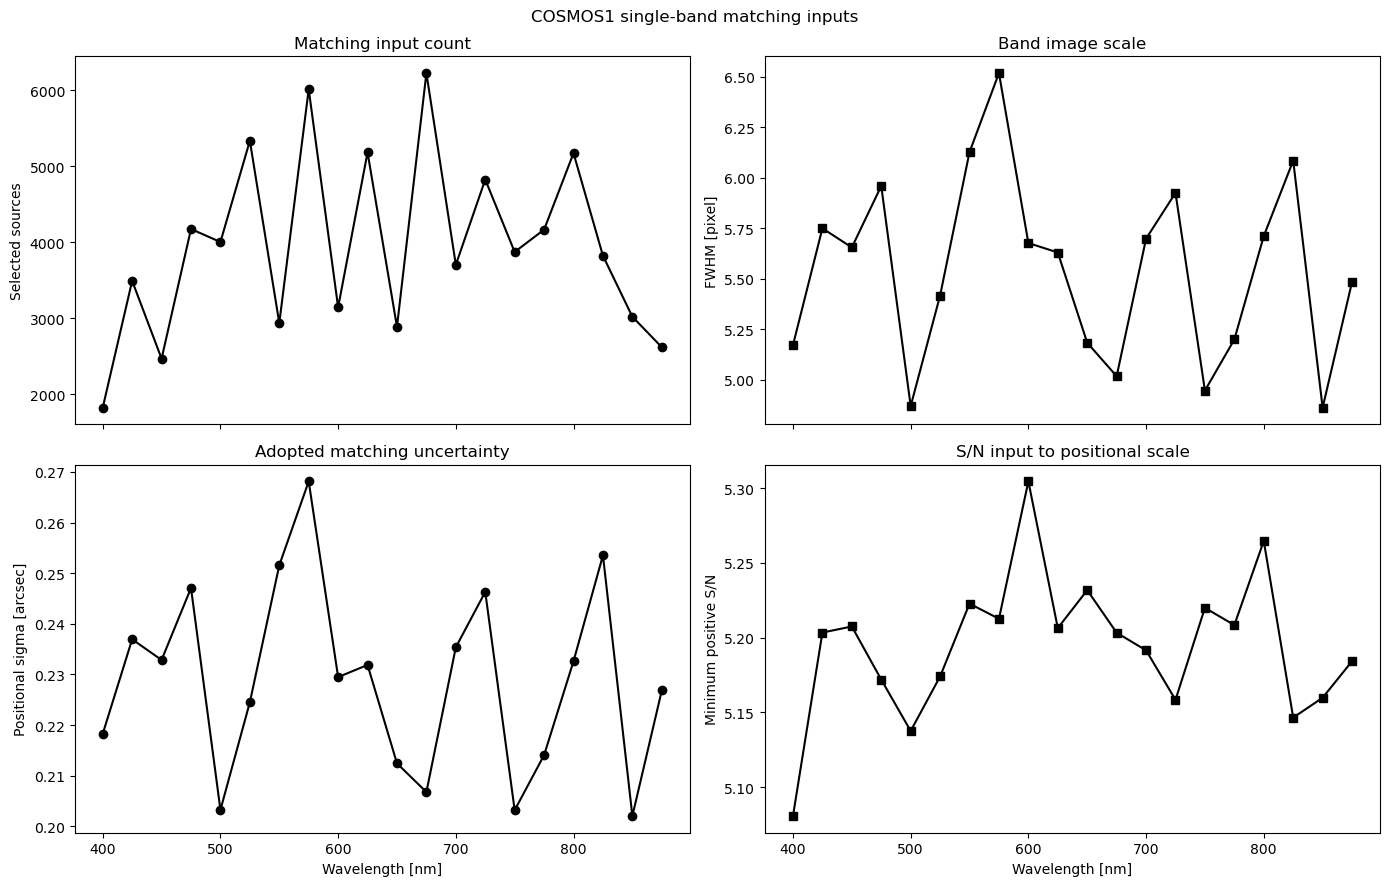

In [6]:
MATCH_FIG_DIR.mkdir(parents=True, exist_ok=True)
wavelength = np.asarray([int(str(band)[1:]) for band in band_uncertainty["band"]])

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes[0, 0].plot(wavelength, band_uncertainty["n_matching"], "o-", color="black")
axes[0, 0].set(ylabel="Selected sources", title="Matching input count")
axes[0, 1].plot(wavelength, band_uncertainty["fwhm_pix"], "s-", color="black")
axes[0, 1].set(ylabel="FWHM [pixel]", title="Band image scale")
axes[1, 0].plot(wavelength, band_uncertainty["sigma_arcsec"], "o-", color="black")
axes[1, 0].set(xlabel="Wavelength [nm]", ylabel="Positional sigma [arcsec]",
               title="Adopted matching uncertainty")
axes[1, 1].plot(wavelength, band_uncertainty["min_snrratio"], "s-", color="black")
axes[1, 1].set(xlabel="Wavelength [nm]", ylabel="Minimum positive S/N",
               title="S/N input to positional scale")
fig.suptitle(f"COSMOS{COSMOS} single-band matching inputs")
fig.tight_layout()
fig.savefig(MATCH_FIG_DIR / "singleband_input_summary.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. 7DT Cross-band Matching


In [7]:
core_paths = {
    "catalog": MATCH_DIR / "matching_catalog_7dt.fits",
    "diagnostics": MATCH_DIR / "matching_diagnostics_7dt.fits",
    "consistency": MATCH_DIR / "consistency_diagnostics_7dt.fits",
}
exists = {name: path.exists() for name, path in core_paths.items()}
if not OVERWRITE_MATCHING and any(exists.values()) and not all(exists.values()):
    raise RuntimeError(f"Incomplete matching products: {exists}. Remove MATCH_DIR and rerun.")

if not OVERWRITE_MATCHING and all(exists.values()):
    matching_table = Table.read(core_paths["catalog"])
    matching_diagnostics = Table.read(core_paths["diagnostics"])
    consistency_diagnostics = Table.read(core_paths["consistency"])
    MATCHING_LOADED = True
    print("Loaded existing 7DT matching products.")
else:
    MATCHING_LOADED = False
    K_MATCH = 3.0

    def wavelength(band):
        return int(band[1:])

    def usable_mag(value):
        return bool(np.isfinite(float(value)) and float(value) != 0.0)

    def reference_mag(master, new_band):
        choices = []
        for band, mag in master["magnitudes_by_band"].items():
            if usable_mag(mag):
                choices.append((abs(wavelength(band) - wavelength(new_band)), wavelength(band), band, float(mag)))
        if not choices:
            return "", np.nan
        _, _, band, mag = min(choices)
        return band, mag

    def new_master(x, y, sigma, band, source_id, mag):
        weight = 1.0 / float(sigma) ** 2
        return {
            "master_id": None,
            "sum_w": weight,
            "sum_wx": weight * float(x),
            "sum_wy": weight * float(y),
            "x": float(x),
            "y": float(y),
            "sigma_master": float(sigma),
            "source_ids_by_band": {band: int(source_id)},
            "magnitudes_by_band": {band: float(mag)},
            "members": [{"band": band, "source_id": int(source_id), "x": float(x), "y": float(y),
                         "sigma_band": float(sigma), "mag": float(mag)}],
        }

    def update_master(master, x, y, sigma, band, source_id, mag):
        weight = 1.0 / float(sigma) ** 2
        master["sum_w"] += weight
        master["sum_wx"] += weight * float(x)
        master["sum_wy"] += weight * float(y)
        master["x"] = master["sum_wx"] / master["sum_w"]
        master["y"] = master["sum_wy"] / master["sum_w"]
        master["sigma_master"] = 1.0 / np.sqrt(master["sum_w"])
        master["source_ids_by_band"][band] = int(source_id)
        master["magnitudes_by_band"][band] = float(mag)
        master["members"].append({"band": band, "source_id": int(source_id), "x": float(x), "y": float(y),
                                  "sigma_band": float(sigma), "mag": float(mag)})

    first = available_band[0]
    master_states = []
    diagnostic_rows = []
    first_cat = matching_catalogs[first]
    for source in first_cat:
        master = new_master(source["pixel_centroid_x"], source["pixel_centroid_y"], band_sigma[first],
                            first, source["source_id"], source["aper3_mag"])
        master["master_id"] = len(master_states)
        master_states.append(master)
        diagnostic_rows.append({
            "band": first, "source_id": int(source["source_id"]), "master_id": master["master_id"],
            "candidate_master_id": master["master_id"], "source_x": float(source["pixel_centroid_x"]),
            "source_y": float(source["pixel_centroid_y"]), "source_ra": float(source["world_centroid_alpha"]),
            "source_dec": float(source["world_centroid_delta"]), "sigma_band": band_sigma[first],
            "master_x_at_match": float(source["pixel_centroid_x"]),
            "master_y_at_match": float(source["pixel_centroid_y"]), "sigma_master_at_match": band_sigma[first],
            "separation": 0.0, "sigma_match": band_sigma[first], "normalized_separation": 0.0,
            "number_of_positional_candidates": 1, "magnitude_reference_band": "",
            "magnitude_difference": np.nan, "ambiguous": False, "candidate_rank": 0,
            "selected": True, "match_status": "initialized",
        })

    for band in tqdm(available_band[1:], desc="7DT matching"):
        cat = matching_catalogs[band]
        sigma_band = band_sigma[band]
        xs = np.asarray(cat["pixel_centroid_x"], dtype=float)
        ys = np.asarray(cat["pixel_centroid_y"], dtype=float)
        mags = np.asarray(cat["aper3_mag"], dtype=float)
        source_ids = np.asarray(cat["source_id"], dtype=int)
        ras = np.asarray(cat["world_centroid_alpha"], dtype=float)
        decs = np.asarray(cat["world_centroid_delta"], dtype=float)
        mx = np.asarray([master["x"] for master in master_states], dtype=float)
        my = np.asarray([master["y"] for master in master_states], dtype=float)
        msigma = np.asarray([master["sigma_master"] for master in master_states], dtype=float)
        tree = cKDTree(np.column_stack([mx, my]))
        max_radius = K_MATCH * np.sqrt(np.max(msigma) ** 2 + sigma_band ** 2)
        neighborhoods = tree.query_ball_point(np.column_stack([xs, ys]), r=max_radius)
        candidates = {}
        for i, neighborhood in enumerate(neighborhoods):
            edges = []
            for j in neighborhood:
                sigma_match = float(np.sqrt(msigma[j] ** 2 + sigma_band ** 2))
                separation = float(np.hypot(xs[i] - mx[j], ys[i] - my[j]))
                if separation >= K_MATCH * sigma_match:
                    continue
                ref_band, ref_mag = reference_mag(master_states[j], band)
                delta_mag = abs(mags[i] - ref_mag) if ref_band and np.isfinite(mags[i]) else np.nan
                edges.append({"master": int(j), "separation": separation, "sigma_match": sigma_match,
                              "D": separation / sigma_match, "ref_band": ref_band, "delta_mag": delta_mag})

            def edge_rank(edge):
                if np.isfinite(edge["delta_mag"]):
                    return (0, edge["delta_mag"], edge["master"])
                return (1, edge["D"], edge["master"])

            edges.sort(key=edge_rank)
            for rank, edge in enumerate(edges):
                edge["rank"] = rank
            candidates[i] = edges

        assignments = {}
        taken_masters = set()
        unique_sources = [i for i, edges in candidates.items() if len(edges) == 1]
        unique_sources.sort(key=lambda i: (candidates[i][0]["D"], i))
        for i in unique_sources:
            j = candidates[i][0]["master"]
            if j not in taken_masters:
                assignments[i] = j
                taken_masters.add(j)

        ambiguous_sources = [i for i, edges in candidates.items() if len(edges) > 1]
        ambiguous_sources.sort(key=lambda i: (
            0 if np.isfinite(candidates[i][0]["delta_mag"]) else 1,
            candidates[i][0]["delta_mag"] if np.isfinite(candidates[i][0]["delta_mag"]) else candidates[i][0]["D"],
            i,
        ))
        for i in ambiguous_sources:
            for edge in candidates[i]:
                if edge["master"] not in taken_masters:
                    assignments[i] = edge["master"]
                    taken_masters.add(edge["master"])
                    break

        for i in range(len(cat)):
            edges = candidates[i]
            if i in assignments:
                chosen = assignments[i]
                master = master_states[chosen]
                selected_edge = next(edge for edge in edges if edge["master"] == chosen)
                if len(edges) == 1:
                    selected_status = "matched_unique"
                elif np.isfinite(selected_edge["delta_mag"]):
                    selected_status = "matched_magnitude"
                else:
                    selected_status = "matched_position_fallback"
                for edge in edges:
                    is_selected = edge["master"] == chosen
                    diagnostic_rows.append({
                        "band": band, "source_id": int(source_ids[i]), "master_id": int(chosen),
                        "candidate_master_id": edge["master"], "source_x": xs[i], "source_y": ys[i],
                        "source_ra": ras[i], "source_dec": decs[i], "sigma_band": sigma_band,
                        "master_x_at_match": mx[edge["master"]], "master_y_at_match": my[edge["master"]],
                        "sigma_master_at_match": msigma[edge["master"]], "separation": edge["separation"],
                        "sigma_match": edge["sigma_match"], "normalized_separation": edge["D"],
                        "number_of_positional_candidates": len(edges),
                        "magnitude_reference_band": edge["ref_band"],
                        "magnitude_difference": edge["delta_mag"], "ambiguous": len(edges) > 1,
                        "candidate_rank": edge["rank"], "selected": is_selected,
                        "match_status": selected_status if is_selected else "rejected_one_to_one",
                    })
                update_master(master, xs[i], ys[i], sigma_band, band, source_ids[i], mags[i])
            else:
                new_status = "new_master_no_candidate" if not edges else "new_master_conflict"
                for edge in edges:
                    diagnostic_rows.append({
                        "band": band, "source_id": int(source_ids[i]), "master_id": -1,
                        "candidate_master_id": edge["master"], "source_x": xs[i], "source_y": ys[i],
                        "source_ra": ras[i], "source_dec": decs[i], "sigma_band": sigma_band,
                        "master_x_at_match": mx[edge["master"]], "master_y_at_match": my[edge["master"]],
                        "sigma_master_at_match": msigma[edge["master"]], "separation": edge["separation"],
                        "sigma_match": edge["sigma_match"], "normalized_separation": edge["D"],
                        "number_of_positional_candidates": len(edges),
                        "magnitude_reference_band": edge["ref_band"],
                        "magnitude_difference": edge["delta_mag"], "ambiguous": len(edges) > 1,
                        "candidate_rank": edge["rank"], "selected": False,
                        "match_status": "rejected_one_to_one",
                    })
                master = new_master(xs[i], ys[i], sigma_band, band, source_ids[i], mags[i])
                master["master_id"] = len(master_states)
                master_states.append(master)
                diagnostic_rows.append({
                    "band": band, "source_id": int(source_ids[i]), "master_id": master["master_id"],
                    "candidate_master_id": master["master_id"], "source_x": xs[i], "source_y": ys[i],
                    "source_ra": ras[i], "source_dec": decs[i], "sigma_band": sigma_band,
                    "master_x_at_match": np.nan, "master_y_at_match": np.nan,
                    "sigma_master_at_match": np.nan, "separation": np.nan, "sigma_match": np.nan,
                    "normalized_separation": np.nan, "number_of_positional_candidates": len(edges),
                    "magnitude_reference_band": "", "magnitude_difference": np.nan,
                    "ambiguous": len(edges) > 1, "candidate_rank": -1, "selected": True,
                    "match_status": new_status,
                })

    matching_table = Table(masked=True)
    matching_table["master_id"] = np.arange(len(master_states), dtype=np.int64)
    for band in BANDS_7DT:
        matching_table[f"{band}_source_id"] = MaskedColumn(
            np.zeros(len(master_states), dtype=np.int64), mask=np.ones(len(master_states), dtype=bool)
        )
    for master in master_states:
        for band, source_id in master["source_ids_by_band"].items():
            matching_table[f"{band}_source_id"][master["master_id"]] = source_id

    matching_diagnostics = Table(rows=diagnostic_rows)
    consistency_rows = []
    for master in master_states:
        sum_w = sum(1.0 / member["sigma_band"] ** 2 for member in master["members"])
        final_x = sum(member["x"] / member["sigma_band"] ** 2 for member in master["members"]) / sum_w
        final_y = sum(member["y"] / member["sigma_band"] ** 2 for member in master["members"]) / sum_w
        final_sigma = 1.0 / np.sqrt(sum_w)
        for member in master["members"]:
            residual = float(np.hypot(member["x"] - final_x, member["y"] - final_y))
            normalized = residual / np.sqrt(final_sigma ** 2 + member["sigma_band"] ** 2)
            consistency_rows.append({
                "master_id": master["master_id"], "band": member["band"],
                "source_id": member["source_id"], "source_x": member["x"], "source_y": member["y"],
                "final_master_x": final_x, "final_master_y": final_y,
                "sigma_band": member["sigma_band"], "sigma_master_final": final_sigma,
                "residual": residual, "normalized_residual": normalized,
                "consistency_flag": "suspect" if normalized >= 3 else "ok",
            })
    consistency_diagnostics = Table(rows=consistency_rows)
    matching_table.write(core_paths["catalog"], overwrite=True)
    matching_diagnostics.write(core_paths["diagnostics"], overwrite=True)
    consistency_diagnostics.write(core_paths["consistency"], overwrite=True)
    print(f"Saved {len(matching_table)} 7DT masters and {len(consistency_diagnostics)} accepted members.")


Loaded existing 7DT matching products.


## 4. FINALCAT Footprint and Pseudo-band Matching


In [8]:
union_paths = {
    "master": MATCH_DIR / "master_catalog.fits",
    "diagnostics": MATCH_DIR / "finalcat_matching_diagnostics.fits",
    "radius": MATCH_DIR / "finalcat_radius_diagnostics.fits",
}
exists = {name: path.exists() for name, path in union_paths.items()}
if not OVERWRITE_MATCHING and any(exists.values()) and not all(exists.values()):
    raise RuntimeError(f"Incomplete union products: {exists}. Remove MATCH_DIR and rerun.")

if not OVERWRITE_MATCHING and all(exists.values()):
    master_catalog = Table.read(union_paths["master"])
    finalcat_matching_diagnostics = Table.read(union_paths["diagnostics"])
    finalcat_radius_diagnostics = Table.read(union_paths["radius"])
    print("Loaded existing FINALCAT union products.")
else:
    finalcat = Table.read(FINALCAT_PATH, hdu=1)
    finalcat_ra = np.asarray(finalcat["RA"], dtype=float)
    finalcat_dec = np.asarray(finalcat["DEC"], dtype=float)
    finalcat_x0, finalcat_y0 = wcs.all_world2pix(finalcat_ra, finalcat_dec, 0)
    in_footprint = positions_in_valid_mask(finalcat_x0, finalcat_y0, origin=0)
    finalcat_indices = np.flatnonzero(in_footprint)
    finalcat_valid = finalcat[in_footprint]
    fra = finalcat_ra[in_footprint]
    fdec = finalcat_dec[in_footprint]

    mids_raw = np.asarray(consistency_diagnostics["master_id"], dtype=int)
    _, first_index = np.unique(mids_raw, return_index=True)
    final_position = {
        int(mids_raw[index]): (
            float(consistency_diagnostics["final_master_x"][index]),
            float(consistency_diagnostics["final_master_y"][index]),
            float(consistency_diagnostics["sigma_master_final"][index]),
        )
        for index in first_index
    }
    master_ids_7dt = np.asarray(matching_table["master_id"], dtype=np.int64)
    x_7dt = np.asarray([final_position[int(mid)][0] for mid in master_ids_7dt], dtype=float)
    y_7dt = np.asarray([final_position[int(mid)][1] for mid in master_ids_7dt], dtype=float)
    sigma_7dt_pix = np.asarray([final_position[int(mid)][2] for mid in master_ids_7dt], dtype=float)
    ra_7dt, dec_7dt = wcs.all_pix2world(x_7dt, y_7dt, 1)
    ra_7dt = np.asarray(ra_7dt, dtype=float)
    dec_7dt = np.asarray(dec_7dt, dtype=float)

    coords_7dt = SkyCoord(ra_7dt * u.deg, dec_7dt * u.deg)
    coords_finalcat = SkyCoord(fra * u.deg, fdec * u.deg)

    def candidate_pairs(coords_external, radius_arcsec):
        index_7dt, index_external, separation, _ = search_around_sky(
            coords_7dt, coords_external, radius_arcsec * u.arcsec
        )
        return (
            np.asarray(index_7dt, dtype=int),
            np.asarray(index_external, dtype=int),
            np.asarray(separation.to_value(u.arcsec), dtype=float),
        )

    def greedy_assignment(index_7dt, index_external, separation, n_external):
        selected = np.zeros(len(separation), dtype=bool)
        used_7dt = np.zeros(len(coords_7dt), dtype=bool)
        used_external = np.zeros(n_external, dtype=bool)
        for edge in np.argsort(separation, kind="stable"):
            i = index_7dt[edge]
            j = index_external[edge]
            if used_7dt[i] or used_external[j]:
                continue
            selected[edge] = True
            used_7dt[i] = True
            used_external[j] = True
        return selected

    radius_rows = []
    for radius in FINALCAT_RADIUS_GRID_ARCSEC:
        i7, jf, sep = candidate_pairs(coords_finalcat, radius)
        selected = greedy_assignment(i7, jf, sep, len(finalcat_valid))
        selected_sep = sep[selected]
        radius_rows.append({
            "sample": "actual", "radius_arcsec": radius, "shift_ra_arcsec": 0.0,
            "shift_dec_arcsec": 0.0, "n_candidate_pairs": len(sep),
            "n_selected": int(selected.sum()),
            "median_sep_arcsec": float(np.median(selected_sep)) if len(selected_sep) else np.nan,
            "p95_sep_arcsec": float(np.percentile(selected_sep, 95)) if len(selected_sep) else np.nan,
        })
        for shift_ra, shift_dec in RANDOM_SHIFTS_ARCSEC:
            shifted_ra = fra + shift_ra / (3600.0 * np.cos(np.deg2rad(fdec)))
            shifted_dec = fdec + shift_dec / 3600.0
            shifted = SkyCoord(shifted_ra * u.deg, shifted_dec * u.deg)
            ri7, rjf, rsep = candidate_pairs(shifted, radius)
            rselected = greedy_assignment(ri7, rjf, rsep, len(finalcat_valid))
            selected_sep = rsep[rselected]
            radius_rows.append({
                "sample": "random", "radius_arcsec": radius, "shift_ra_arcsec": shift_ra,
                "shift_dec_arcsec": shift_dec, "n_candidate_pairs": len(rsep),
                "n_selected": int(rselected.sum()),
                "median_sep_arcsec": float(np.median(selected_sep)) if len(selected_sep) else np.nan,
                "p95_sep_arcsec": float(np.percentile(selected_sep, 95)) if len(selected_sep) else np.nan,
            })
    finalcat_radius_diagnostics = Table(rows=radius_rows)

    index_7dt, index_finalcat, separation = candidate_pairs(
        coords_finalcat, FINALCAT_MATCH_RADIUS_ARCSEC
    )
    selected_edge = greedy_assignment(index_7dt, index_finalcat, separation, len(finalcat_valid))
    n_master_candidates = np.bincount(index_finalcat, minlength=len(finalcat_valid))
    n_finalcat_candidates = np.bincount(index_7dt, minlength=len(matching_table))
    matched_finalcat = np.zeros(len(finalcat_valid), dtype=bool)
    matched_7dt = np.zeros(len(matching_table), dtype=bool)
    finalcat_local_by_7dt = np.full(len(matching_table), -1, dtype=int)
    separation_by_7dt = np.full(len(matching_table), np.nan, dtype=float)
    for edge in np.flatnonzero(selected_edge):
        i = index_7dt[edge]
        j = index_finalcat[edge]
        matched_7dt[i] = True
        matched_finalcat[j] = True
        finalcat_local_by_7dt[i] = j
        separation_by_7dt[i] = separation[edge]

    unmatched_finalcat_local = np.flatnonzero(~matched_finalcat)
    n_7dt = len(matching_table)
    n_finalcat_only = len(unmatched_finalcat_local)
    n_total = n_7dt + n_finalcat_only
    next_master_id = int(master_ids_7dt.max()) + 1 if n_7dt else 0
    new_master_ids = np.arange(next_master_id, next_master_id + n_finalcat_only, dtype=np.int64)
    master_ids = np.concatenate([master_ids_7dt, new_master_ids])
    finalcat_local_by_master = np.full(n_total, -1, dtype=int)
    finalcat_local_by_master[:n_7dt] = finalcat_local_by_7dt
    finalcat_local_by_master[n_7dt:] = unmatched_finalcat_local
    has_7dt = np.arange(n_total) < n_7dt
    has_finalcat = finalcat_local_by_master >= 0

    master_class = np.full(n_total, "finalcat_only", dtype="<U16")
    master_class[:n_7dt] = np.where(matched_7dt, "matched", "7dt_only")
    position_origin = np.where(has_7dt, "7dt_weighted", "finalcat")

    finalcat_x1, finalcat_y1 = wcs.all_world2pix(fra, fdec, 1)
    master_x = np.concatenate([x_7dt, finalcat_x1[unmatched_finalcat_local]])
    master_y = np.concatenate([y_7dt, finalcat_y1[unmatched_finalcat_local]])
    master_ra = np.concatenate([ra_7dt, fra[unmatched_finalcat_local]])
    master_dec = np.concatenate([dec_7dt, fdec[unmatched_finalcat_local]])

    master_catalog = Table(masked=True)
    master_catalog["master_id"] = master_ids
    master_catalog["master_class"] = master_class
    master_catalog["has_7dt"] = has_7dt
    master_catalog["has_finalcat"] = has_finalcat
    master_catalog["position_origin"] = position_origin
    master_catalog["master_x"] = master_x
    master_catalog["master_y"] = master_y
    master_catalog["master_ra"] = master_ra
    master_catalog["master_dec"] = master_dec
    master_catalog["x_7dt"] = MaskedColumn(
        np.concatenate([x_7dt, np.full(n_finalcat_only, np.nan)]), mask=~has_7dt
    )
    master_catalog["y_7dt"] = MaskedColumn(
        np.concatenate([y_7dt, np.full(n_finalcat_only, np.nan)]), mask=~has_7dt
    )
    master_catalog["ra_7dt"] = MaskedColumn(
        np.concatenate([ra_7dt, np.full(n_finalcat_only, np.nan)]), mask=~has_7dt
    )
    master_catalog["dec_7dt"] = MaskedColumn(
        np.concatenate([dec_7dt, np.full(n_finalcat_only, np.nan)]), mask=~has_7dt
    )
    master_catalog["sigma_7dt_pix"] = MaskedColumn(
        np.concatenate([sigma_7dt_pix, np.full(n_finalcat_only, np.nan)]), mask=~has_7dt
    )

    n_7dt_bands = np.zeros(n_total, dtype=np.int16)
    for band in BANDS_7DT:
        source_col = matching_table[f"{band}_source_id"]
        source_mask_7dt = np.ma.getmaskarray(source_col)
        source_data = np.zeros(n_total, dtype=np.int64)
        source_mask = np.ones(n_total, dtype=bool)
        source_data[:n_7dt] = np.ma.filled(source_col, 0)
        source_mask[:n_7dt] = source_mask_7dt
        master_catalog[f"{band}_source_id"] = MaskedColumn(source_data, mask=source_mask)
        n_7dt_bands[:n_7dt] += (~source_mask_7dt).astype(np.int16)

        raw = catalogs[band]
        raw_ids = np.asarray(raw["source_id"], dtype=np.int64)
        if len(np.unique(raw_ids)) != len(raw_ids):
            raise ValueError(f"{band}: source_id is not unique")
        lookup = {int(source_id): row for row, source_id in enumerate(raw_ids)}
        mag_data = np.full(n_total, np.nan, dtype=np.float32)
        mag_err_data = np.full(n_total, np.nan, dtype=np.float32)
        mag_mask = source_mask.copy()
        rows = np.flatnonzero(~source_mask[:n_7dt])
        raw_rows = np.asarray([lookup[int(source_data[row])] for row in rows], dtype=int)
        mag_data[rows] = np.asarray(raw["aper3_mag"], dtype=np.float32)[raw_rows]
        mag_err_data[rows] = np.asarray(raw["aper3_mag_err"], dtype=np.float32)[raw_rows]
        master_catalog[f"{band}_mag"] = MaskedColumn(mag_data, mask=mag_mask, unit="mag")
        master_catalog[f"{band}_mag_err"] = MaskedColumn(mag_err_data, mask=mag_mask, unit="mag")

    master_catalog.add_column(n_7dt_bands, name="n_7dt_bands", index=4)

    finalcat_idx_data = np.full(n_total, -1, dtype=np.int64)
    finalcat_idx_mask = ~has_finalcat
    final_rows = np.flatnonzero(has_finalcat)
    final_locals = finalcat_local_by_master[final_rows]
    finalcat_idx_data[final_rows] = finalcat_indices[final_locals]
    master_catalog["finalcat_idx"] = MaskedColumn(finalcat_idx_data, mask=finalcat_idx_mask)
    sep_data = np.full(n_total, np.nan, dtype=float)
    sep_mask = np.ones(n_total, dtype=bool)
    sep_data[:n_7dt] = separation_by_7dt
    sep_mask[:n_7dt] = ~matched_7dt
    master_catalog["finalcat_sep_arcsec"] = MaskedColumn(sep_data, mask=sep_mask, unit="arcsec")
    candidate_data = np.zeros(n_total, dtype=np.int32)
    candidate_data[final_rows] = n_master_candidates[final_locals]
    master_catalog["finalcat_n_candidates"] = MaskedColumn(candidate_data, mask=finalcat_idx_mask)

    finalcat_status = np.full(n_total, "unmatched", dtype="<U24")
    for row in np.flatnonzero(matched_7dt):
        local = finalcat_local_by_master[row]
        unique = n_master_candidates[local] == 1 and n_finalcat_candidates[row] == 1
        finalcat_status[row] = "matched_unique" if unique else "matched_ambiguous"
    for offset, local in enumerate(unmatched_finalcat_local):
        finalcat_status[n_7dt + offset] = (
            "new_master_no_candidate" if n_master_candidates[local] == 0 else "new_master_conflict"
        )
    master_catalog["finalcat_match_status"] = finalcat_status

    # Preserve every FINALCAT column under an explicit namespace.
    for column_name in finalcat.colnames:
        source = finalcat_valid[column_name]
        source_data = np.asarray(source)
        source_mask = np.ma.getmaskarray(source)
        data = np.zeros(n_total, dtype=source_data.dtype)
        mask = np.ones(n_total, dtype=bool)
        data[final_rows] = source_data[final_locals]
        mask[final_rows] = source_mask[final_locals]
        output = MaskedColumn(data, mask=mask, name=f"finalcat_{column_name}")
        if getattr(source, "unit", None) is not None:
            output.unit = source.unit
        master_catalog.add_column(output)

    def text_value(value):
        return value.decode(errors="replace") if isinstance(value, (bytes, np.bytes_)) else str(value)

    diagnostic_rows = []
    selected_lookup = set(np.flatnonzero(selected_edge).tolist())
    final_master_id_by_finalcat = np.full(len(finalcat_valid), -1, dtype=np.int64)
    final_master_id_by_finalcat[finalcat_local_by_master[has_finalcat]] = master_ids[has_finalcat]
    assert np.all(final_master_id_by_finalcat >= 0)
    for edge in range(len(separation)):
        i = index_7dt[edge]
        j = index_finalcat[edge]
        selected = edge in selected_lookup
        unique = n_master_candidates[j] == 1 and n_finalcat_candidates[i] == 1
        diagnostic_rows.append({
            "finalcat_idx": int(finalcat_indices[j]),
            "finalcat_id": text_value(finalcat_valid["ID"][j]),
            "final_master_id": int(final_master_id_by_finalcat[j]),
            "candidate_master_id": int(master_ids_7dt[i]),
            "separation_arcsec": float(separation[edge]),
            "match_radius_arcsec": FINALCAT_MATCH_RADIUS_ARCSEC,
            "n_master_candidates": int(n_master_candidates[j]),
            "n_finalcat_candidates_for_master": int(n_finalcat_candidates[i]),
            "selected": selected,
            "match_status": (
                "matched_unique" if selected and unique else
                "matched_ambiguous" if selected else "rejected_one_to_one"
            ),
        })
    for local in unmatched_finalcat_local:
        diagnostic_rows.append({
            "finalcat_idx": int(finalcat_indices[local]),
            "finalcat_id": text_value(finalcat_valid["ID"][local]),
            "final_master_id": int(final_master_id_by_finalcat[local]),
            "candidate_master_id": -1,
            "separation_arcsec": np.nan,
            "match_radius_arcsec": FINALCAT_MATCH_RADIUS_ARCSEC,
            "n_master_candidates": int(n_master_candidates[local]),
            "n_finalcat_candidates_for_master": 0,
            "selected": True,
            "match_status": (
                "new_master_no_candidate" if n_master_candidates[local] == 0 else "new_master_conflict"
            ),
        })
    finalcat_matching_diagnostics = Table(rows=diagnostic_rows)

    # Core integrity checks before writing the authoritative catalog.
    assert len(np.unique(master_ids)) == n_total
    assert int(has_finalcat.sum()) == len(finalcat_valid)
    assert int((master_class == "matched").sum() + (master_class == "7dt_only").sum()) == n_7dt
    assert int((master_class == "matched").sum() + (master_class == "finalcat_only").sum()) == len(finalcat_valid)
    assert np.all(np.isfinite(master_x) & np.isfinite(master_y))
    assert np.all(np.isfinite(master_ra) & np.isfinite(master_dec))
    if selected_edge.any():
        assert float(np.max(separation[selected_edge])) <= FINALCAT_MATCH_RADIUS_ARCSEC

    master_catalog.meta["COSMOS"] = COSMOS
    master_catalog.meta["MASKFILE"] = MASK_PATH.name
    master_catalog.meta["FINCAT"] = FINALCAT_PATH.name
    master_catalog.meta["RADIUS"] = FINALCAT_MATCH_RADIUS_ARCSEC
    master_catalog.meta["NBANDS"] = len(BANDS_7DT)
    master_catalog.meta["POSITION"] = "7DT weighted; FINALCAT for FINALCAT-only"
    master_catalog.write(union_paths["master"], overwrite=True)
    finalcat_matching_diagnostics.write(union_paths["diagnostics"], overwrite=True)
    finalcat_radius_diagnostics.write(union_paths["radius"], overwrite=True)

    print(f"FINALCAT total: {len(finalcat)}")
    print(f"FINALCAT in valid mask: {len(finalcat_valid)}")
    print(f"7DT masters: {n_7dt}")
    print(f"matched: {(master_class == 'matched').sum()}")
    print(f"7dt_only: {(master_class == '7dt_only').sum()}")
    print(f"finalcat_only: {(master_class == 'finalcat_only').sum()}")
    print(f"union masters: {len(master_catalog)}")
    print(f"master columns: {len(master_catalog.colnames)}")


Loaded existing FINALCAT union products.


## 5. Master-catalog Validation and Core Results


In [9]:
# Reload the saved products so this section is independent of transient compute state.
master = Table.read(MATCH_DIR / "master_catalog.fits")
band_uncertainty = Table.read(MATCH_DIR / "band_uncertainty.fits")
matching_diagnostics = Table.read(MATCH_DIR / "matching_diagnostics_7dt.fits")
consistency_diagnostics = Table.read(MATCH_DIR / "consistency_diagnostics_7dt.fits")
finalcat_diagnostics = Table.read(MATCH_DIR / "finalcat_matching_diagnostics.fits")
radius_diagnostics = Table.read(MATCH_DIR / "finalcat_radius_diagnostics.fits")

classes = np.asarray(master["master_class"]).astype(str)
has_7dt = np.asarray(master["has_7dt"], dtype=bool)
has_finalcat = np.asarray(master["has_finalcat"], dtype=bool)
n_bands = np.asarray(master["n_7dt_bands"], dtype=int)

print(f"Master rows: {len(master)}")
print(f"Master columns: {len(master.colnames)}")
for label in ("matched", "7dt_only", "finalcat_only"):
    print(f"{label}: {int((classes == label).sum())}")
print(f"7DT-bearing: {int(has_7dt.sum())}")
print(f"FINALCAT-bearing: {int(has_finalcat.sum())}")
print(f"Strict 20-band: {int((n_bands == 20).sum())}")


Master rows: 75259
Master columns: 237
matched: 2977
7dt_only: 16512
finalcat_only: 55770
7DT-bearing: 19489
FINALCAT-bearing: 58747
Strict 20-band: 1157


### 5.1 Integrity Checks


In [10]:
assert len(np.unique(np.asarray(master["master_id"], dtype=np.int64))) == len(master)
assert np.isin(classes, ["matched", "7dt_only", "finalcat_only"]).all()
assert int(((classes == "matched") | (classes == "7dt_only")).sum()) == int(has_7dt.sum())
assert int(((classes == "matched") | (classes == "finalcat_only")).sum()) == int(has_finalcat.sum())
assert np.all(np.isfinite(np.asarray(master["master_ra"], dtype=float)))
assert np.all(np.isfinite(np.asarray(master["master_dec"], dtype=float)))

for band in BANDS_7DT:
    source_mask = np.ma.getmaskarray(master[f"{band}_source_id"])
    magnitude_mask = np.ma.getmaskarray(master[f"{band}_mag"])
    error_mask = np.ma.getmaskarray(master[f"{band}_mag_err"])
    assert np.array_equal(source_mask, magnitude_mask)
    assert np.array_equal(source_mask, error_mask)

selected = np.asarray(finalcat_diagnostics["selected"], dtype=bool)
status = np.asarray(finalcat_diagnostics["match_status"]).astype(str)
selected_pair = selected & np.isin(status, ["matched_unique", "matched_ambiguous"])
if selected_pair.any():
    separation = np.asarray(finalcat_diagnostics["separation_arcsec"], dtype=float)[selected_pair]
    assert np.nanmax(separation) <= float(master.meta["RADIUS"])

print("All master-catalog integrity checks passed.")


All master-catalog integrity checks passed.


### 5.2 7DT Matching Summary


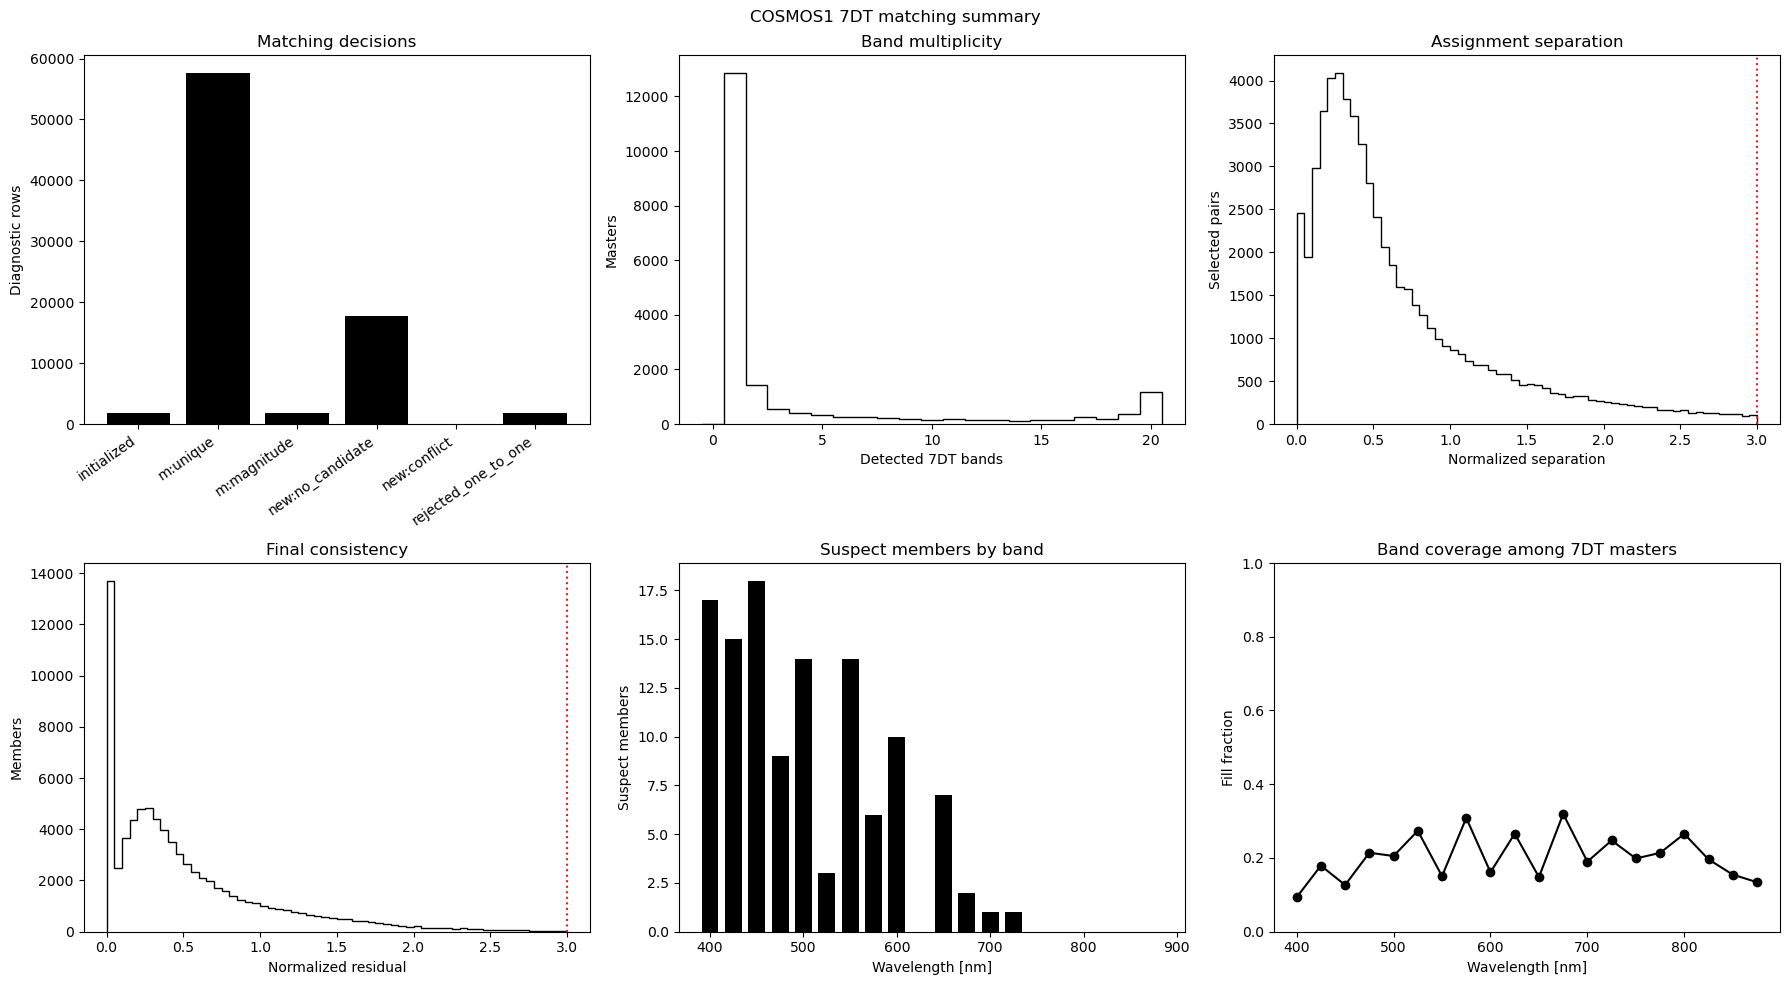

Suspect 7DT members: 117/78882


In [11]:
statuses = np.asarray(matching_diagnostics["match_status"]).astype(str)
status_order = [
    "initialized", "matched_unique", "matched_magnitude", "matched_position_fallback",
    "new_master_no_candidate", "new_master_conflict", "rejected_one_to_one",
]
status_labels = [label for label in status_order if label in set(statuses)]
status_counts = [int((statuses == label).sum()) for label in status_labels]
selected = np.asarray(matching_diagnostics["selected"], dtype=bool)
normalized_separation = np.asarray(
    matching_diagnostics["normalized_separation"], dtype=float
)[selected]
normalized_separation = normalized_separation[np.isfinite(normalized_separation)]
normalized_residual = np.asarray(consistency_diagnostics["normalized_residual"], dtype=float)
normalized_residual = normalized_residual[np.isfinite(normalized_residual)]
consistency_flag = np.asarray(consistency_diagnostics["consistency_flag"]).astype(str)
consistency_band = np.asarray(consistency_diagnostics["band"]).astype(str)
suspect_by_band = np.asarray([
    np.count_nonzero((consistency_band == band) & (consistency_flag == "suspect"))
    for band in BANDS_7DT
])
fill_fraction = np.asarray([
    1.0 - np.mean(np.ma.getmaskarray(master[f"{band}_source_id"])[has_7dt])
    for band in BANDS_7DT
])
wavelength = np.asarray([int(band[1:]) for band in BANDS_7DT])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].bar(np.arange(len(status_labels)), status_counts, color="black")
axes[0, 0].set_xticks(
    np.arange(len(status_labels)),
    [label.replace("matched_", "m:").replace("new_master_", "new:") for label in status_labels],
    rotation=35,
    ha="right",
)
axes[0, 0].set(ylabel="Diagnostic rows", title="Matching decisions")
axes[0, 1].hist(n_bands[has_7dt], bins=np.arange(22) - 0.5, histtype="step", color="black")
axes[0, 1].set(xlabel="Detected 7DT bands", ylabel="Masters", title="Band multiplicity")
axes[0, 2].hist(normalized_separation, bins=60, range=(0, 3), histtype="step", color="black")
axes[0, 2].axvline(3, color="tab:red", linestyle=":")
axes[0, 2].set(xlabel="Normalized separation", ylabel="Selected pairs", title="Assignment separation")
axes[1, 0].hist(normalized_residual, bins=60, range=(0, 3), histtype="step", color="black")
axes[1, 0].axvline(3, color="tab:red", linestyle=":")
axes[1, 0].set(xlabel="Normalized residual", ylabel="Members", title="Final consistency")
axes[1, 1].bar(wavelength, suspect_by_band, width=18, color="black")
axes[1, 1].set(xlabel="Wavelength [nm]", ylabel="Suspect members", title="Suspect members by band")
axes[1, 2].plot(wavelength, fill_fraction, "o-", color="black")
axes[1, 2].set(xlabel="Wavelength [nm]", ylabel="Fill fraction", ylim=(0, 1),
               title="Band coverage among 7DT masters")
fig.suptitle(f"COSMOS{COSMOS} 7DT matching summary")
fig.tight_layout()
fig.savefig(MATCH_FIG_DIR / "7dt_matching_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Suspect 7DT members: {int((consistency_flag == 'suspect').sum())}/{len(consistency_flag)}")


### 5.3 FINALCAT Radius Diagnostics


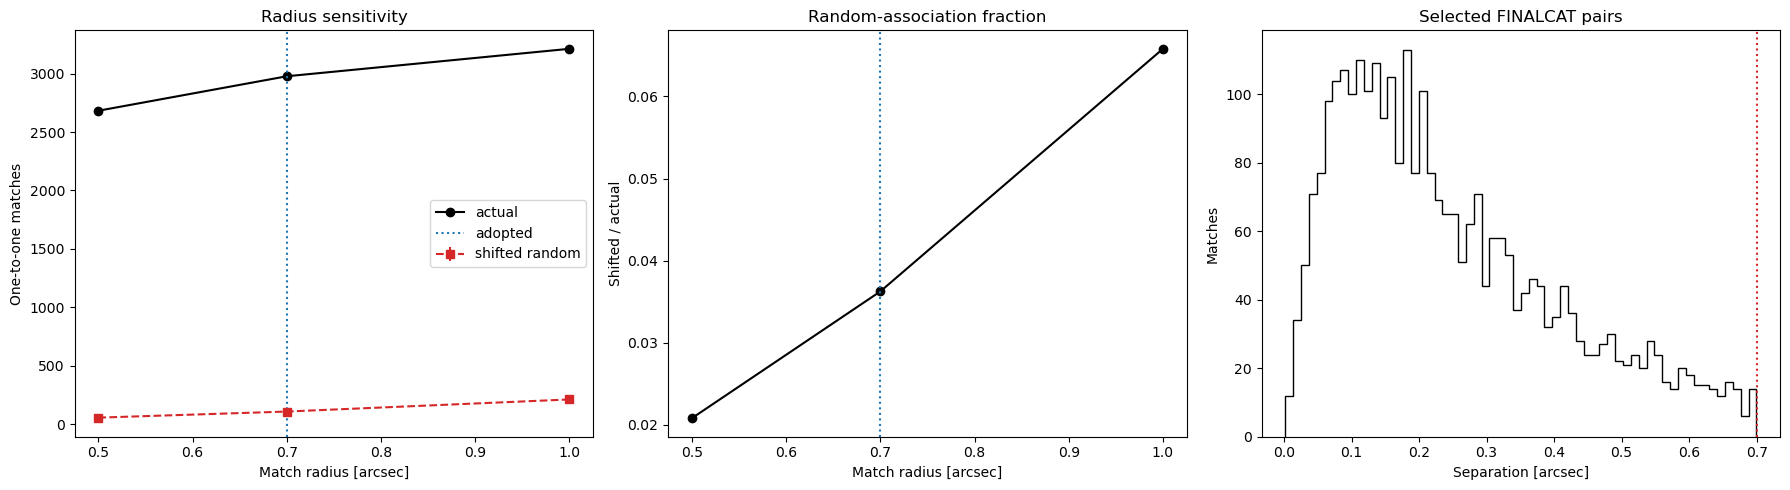

In [12]:
radii = np.unique(np.asarray(radius_diagnostics["radius_arcsec"], dtype=float))
samples = np.asarray(radius_diagnostics["sample"]).astype(str)
radius_values = np.asarray(radius_diagnostics["radius_arcsec"], dtype=float)
n_selected = np.asarray(radius_diagnostics["n_selected"], dtype=int)
actual_matches = []
random_mean = []
random_std = []
for radius in radii:
    at_radius = np.isclose(radius_values, radius)
    actual = n_selected[at_radius & (samples == "actual")]
    random = n_selected[at_radius & (samples == "random")]
    actual_matches.append(int(actual[0]))
    random_mean.append(float(np.mean(random)))
    random_std.append(float(np.std(random)))
actual_matches = np.asarray(actual_matches)
random_mean = np.asarray(random_mean)
random_std = np.asarray(random_std)
random_fraction = random_mean / actual_matches

selected = np.asarray(finalcat_diagnostics["selected"], dtype=bool)
status = np.asarray(finalcat_diagnostics["match_status"]).astype(str)
selected_pair = selected & np.isin(status, ["matched_unique", "matched_ambiguous"])
separation = np.asarray(finalcat_diagnostics["separation_arcsec"], dtype=float)[selected_pair]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(radii, actual_matches, "o-", color="black", label="actual")
axes[0].errorbar(radii, random_mean, yerr=random_std, fmt="s--", color="tab:red", label="shifted random")
axes[0].axvline(float(master.meta["RADIUS"]), color="tab:blue", linestyle=":", label="adopted")
axes[0].set(xlabel="Match radius [arcsec]", ylabel="One-to-one matches", title="Radius sensitivity")
axes[0].legend()
axes[1].plot(radii, random_fraction, "o-", color="black")
axes[1].axvline(float(master.meta["RADIUS"]), color="tab:blue", linestyle=":")
axes[1].set(xlabel="Match radius [arcsec]", ylabel="Shifted / actual", title="Random-association fraction")
axes[2].hist(separation[np.isfinite(separation)], bins=60, histtype="step", color="black")
axes[2].axvline(float(master.meta["RADIUS"]), color="tab:red", linestyle=":")
axes[2].set(xlabel="Separation [arcsec]", ylabel="Matches", title="Selected FINALCAT pairs")
fig.tight_layout()
fig.savefig(MATCH_FIG_DIR / "finalcat_radius_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.4 Master Population Summary


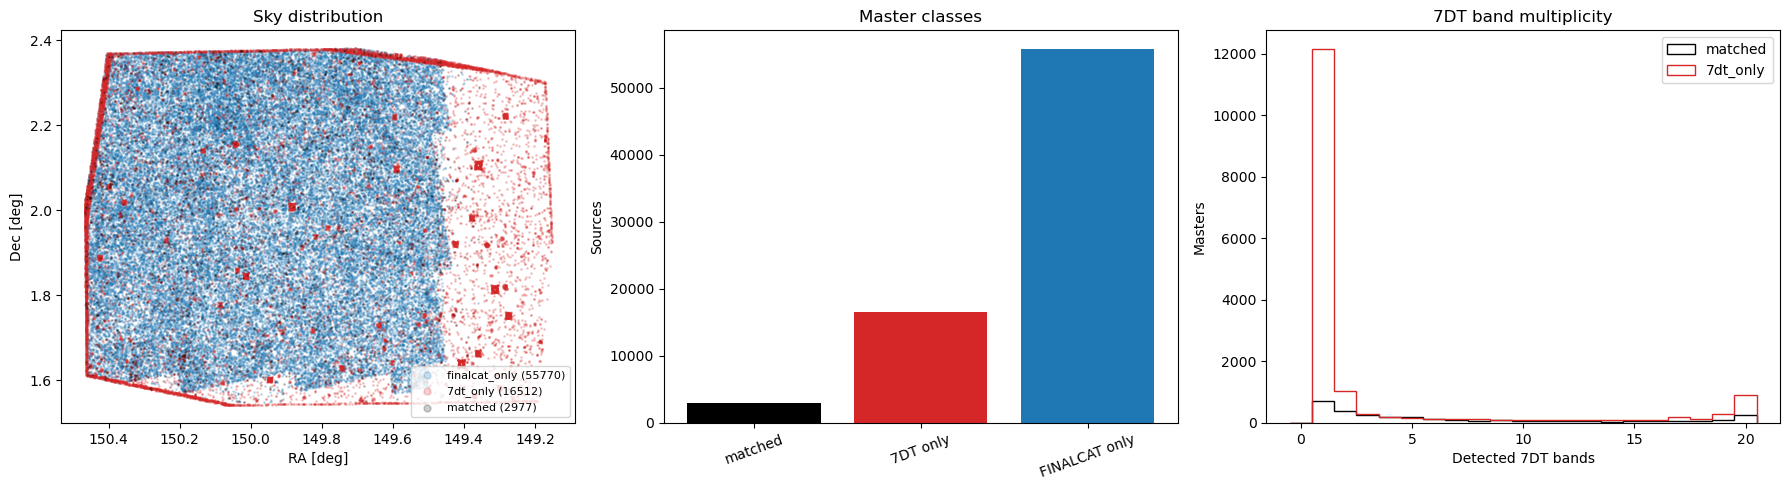

In [13]:
class_colors = {"matched": "black", "7dt_only": "tab:red", "finalcat_only": "tab:blue"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for label in ("finalcat_only", "7dt_only", "matched"):
    choose = classes == label
    axes[0].scatter(
        master["master_ra"][choose], master["master_dec"][choose],
        s=1, alpha=0.2, color=class_colors[label], label=f"{label} ({choose.sum()})",
    )
axes[0].set(xlabel="RA [deg]", ylabel="Dec [deg]", title="Sky distribution")
axes[0].invert_xaxis()
axes[0].legend(markerscale=5, fontsize=8)
axes[1].bar(
    ["matched", "7DT only", "FINALCAT only"],
    [(classes == "matched").sum(), (classes == "7dt_only").sum(), (classes == "finalcat_only").sum()],
    color=[class_colors["matched"], class_colors["7dt_only"], class_colors["finalcat_only"]],
)
axes[1].set(ylabel="Sources", title="Master classes")
axes[1].tick_params(axis="x", rotation=20)
for label in ("matched", "7dt_only"):
    choose = classes == label
    axes[2].hist(
        n_bands[choose], bins=np.arange(22) - 0.5, histtype="step",
        color=class_colors[label], label=label,
    )
axes[2].set(xlabel="Detected 7DT bands", ylabel="Masters", title="7DT band multiplicity")
axes[2].legend()
fig.tight_layout()
fig.savefig(MATCH_FIG_DIR / "master_population_summary.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.5 Strict 20-band Subset


In [14]:
full20 = master[n_bands == 20]
full20_path = MATCH_DIR / "master_full20_catalog.fits"
full20.write(full20_path, overwrite=True)
print(f"Saved {len(full20)} strict 20-band sources to {full20_path}")


Saved 1157 strict 20-band sources to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/master_full20_catalog.fits


## 6. Outputs

The authoritative product is `matching/master_catalog.fits`. Experimental
analysis and future plot methods belong in `notebook2_test.ipynb`.
